In [1]:
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.datasets.universal_dataset import CVADataset
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path

import os
import matplotlib.pyplot as plt

In [2]:
def load_data(drop_inhib: str):
    prep = Pipeline(
        num_cycle=[1, 2, 3, 4], 
        inhibitor_name="all", 
        split="all",
        norm_feat=True
    )
    data = prep.full_data

    train_data, valid_data = select_test_inh(data, drop_inhib)
    
    return train_data, valid_data

In [3]:
INHIBITOR_NAME = "2-mercaptobenzimidazole"
normalize = False

train, val = load_data(drop_inhib=INHIBITOR_NAME)

train_dataset = CVADataset(train, normalize=normalize)
test_dataset = CVADataset(val, normalize=normalize)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [4]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"

vae = GPT(
    cond_dim=41,
    seq_len=968,
    d_model=64,
    nhead=1,
    num_layers=3,
    dropout=0.0011341356530829572
).to(device)

opt_vae = torch.optim.Adam(vae.parameters(), lr=0.0044656972183575155)
scheduler = StepLR(opt_vae, gamma=0.85, step_size=25)

train_denormalize_fn = None
val_denormalize_fn = None

if normalize:
    train_denormalize_fn = train_dataset.denormalize
    val_denormalize_fn = test_dataset.denormalize

/home/smirnov@dohod.local/Desktop/electrochem-digital-twins/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
num_epoch = 300

trainer = Trainer(
    model=vae,
    loss_fn=vae_loss,
    epochs=num_epoch,
    optimizer=opt_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    path_to_save_plots=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    path_to_save_models=os.path.join(get_project_path(), "models", "gpt", INHIBITOR_NAME, "best_model.pt"),
    path_to_save_tables=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    scheduler=scheduler,
    train_denorm_fn=train_denormalize_fn,
    val_denorm_fn=val_denormalize_fn,
    seed=42
)

In [6]:
vae.y_start_emb

Parameter containing:
tensor([[-6.6546e-03,  2.9072e-03,  1.5766e-02, -6.0777e-03,  1.0198e-02,
          1.1862e-02,  7.9131e-03,  4.0755e-03,  5.0374e-03, -6.0600e-04,
          1.6993e-02,  1.8820e-02, -3.0091e-03, -1.3804e-02, -1.9768e-03,
          7.0716e-03,  1.2363e-03, -1.7377e-02,  1.0087e-03,  9.6687e-03,
         -5.0807e-03, -9.6775e-04,  1.6204e-02, -6.0996e-03,  6.1861e-03,
         -1.7333e-03,  1.0201e-03, -7.1097e-03,  3.6178e-03,  2.3083e-03,
         -8.2686e-04, -5.1753e-03, -1.1703e-02,  1.5340e-02, -7.1596e-05,
         -3.0246e-03, -8.0136e-03,  1.3089e-03, -3.4117e-03,  8.0943e-03,
         -6.9671e-03,  7.3694e-03, -1.4181e-02,  1.0812e-03, -4.3633e-04,
          1.0346e-02,  1.9818e-03,  5.3996e-03, -8.0106e-04, -7.8866e-03,
          6.3134e-03,  2.4441e-03,  1.5303e-03, -6.1259e-03,  2.8158e-03,
         -8.2896e-03, -2.2184e-02, -1.8607e-02,  1.1996e-02, -1.0438e-02,
          4.7328e-04,  9.1408e-03,  8.9229e-03, -4.2393e-03]], device='cuda:0',
       req

In [7]:
trainer.train_model()

Epoch 000 — Train Loss: 0.592350, Val Loss: 0.088646, LR: [0.0044656972183575155]
Epoch 001 — Train Loss: 0.084734, Val Loss: 0.059292, LR: [0.0044656972183575155]
Epoch 002 — Train Loss: 0.036858, Val Loss: 0.025428, LR: [0.0044656972183575155]
Epoch 003 — Train Loss: 0.019804, Val Loss: 0.015212, LR: [0.0044656972183575155]
Epoch 004 — Train Loss: 0.012466, Val Loss: 0.011008, LR: [0.0044656972183575155]
Epoch 005 — Train Loss: 0.008337, Val Loss: 0.007862, LR: [0.0044656972183575155]
Epoch 006 — Train Loss: 0.006761, Val Loss: 0.006493, LR: [0.0044656972183575155]
Epoch 007 — Train Loss: 0.005570, Val Loss: 0.005583, LR: [0.0044656972183575155]
Epoch 008 — Train Loss: 0.004933, Val Loss: 0.004941, LR: [0.0044656972183575155]
Epoch 009 — Train Loss: 0.004392, Val Loss: 0.004474, LR: [0.0044656972183575155]
Epoch 010 — Train Loss: 0.003990, Val Loss: 0.004119, LR: [0.0044656972183575155]
Epoch 011 — Train Loss: 0.003825, Val Loss: 0.003814, LR: [0.0044656972183575155]
Epoch 012 — Trai

In [8]:
vae.y_start_emb

Parameter containing:
tensor([[-0.0354,  0.0135,  0.0420, -0.0152,  0.0401, -0.0176, -0.0313,  0.0511,
          0.0225, -0.0280,  0.0300,  0.0599, -0.0348, -0.0470, -0.0386, -0.0330,
         -0.0124,  0.0224,  0.0241, -0.0652, -0.0446, -0.0377,  0.0692, -0.0053,
          0.0550,  0.0060, -0.0055, -0.0397,  0.0289, -0.0236,  0.0098,  0.0155,
          0.0440,  0.0414, -0.0372,  0.0368, -0.0401,  0.0331,  0.0178,  0.0504,
          0.0283,  0.0016,  0.0219,  0.0358, -0.0205, -0.0224, -0.0323,  0.0317,
          0.0081, -0.0441, -0.0263,  0.0119, -0.0020, -0.0279, -0.0030, -0.0086,
         -0.0498, -0.0817, -0.0292,  0.0252, -0.0116, -0.0021, -0.0274, -0.0052]],
       device='cuda:0', requires_grad=True)

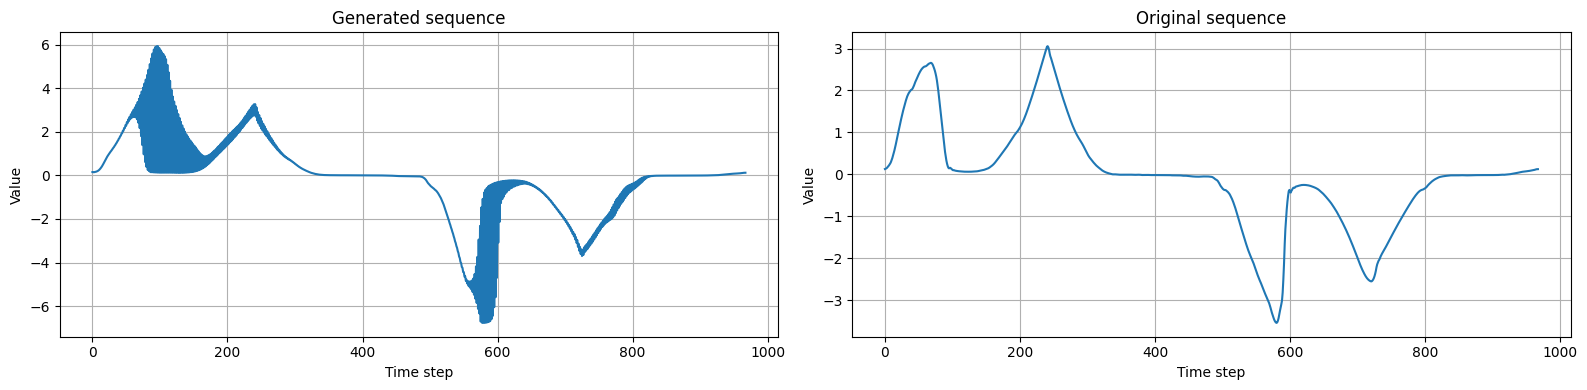

In [9]:
generated_seq = vae.generate(test_dataset[1]['features'].unsqueeze(0).to(device)).squeeze(0).cpu().numpy()  # [968]
test_seq = test_dataset[1]['vah'].cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(generated_seq)
axs[0].set_title("Generated sequence")
axs[0].set_xlabel("Time step")
axs[0].set_ylabel("Value")
axs[0].grid(True)

axs[1].plot(test_seq)
axs[1].set_title("Original sequence")
axs[1].set_xlabel("Time step")
axs[1].set_ylabel("Value")
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
torch.save(vae.state_dict(), 'gpt_24dim_2l.pth')

In [ ]:
import optuna
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.datasets.universal_dataset import CVADataset
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path

import os
import matplotlib.pyplot as plt

INHIBITOR_NAME = "2-mercaptobenzimidazole"
normalize = False  # можно сделать частью поиска, но пока фиксировано

def objective(trial):
    d_model = trial.suggest_int("d_model", 8, 64, step=8)          # 8, 16, ..., 64
    num_layers = trial.suggest_int("num_layers", 1, 4)             # 1–4 слоя
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)           # лог-масштаб

    # === Загрузка данных ===
    train, val = load_data(drop_inhib=INHIBITOR_NAME)
    train_dataset = CVADataset(train, normalize=normalize)
    test_dataset = CVADataset(val, normalize=normalize)

    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    # === Устройство ===
    device = "cuda:0" if torch.cuda.is_available() else "cpu"

    # === Модель ===
    vae = GPT(
        cond_dim=41,
        seq_len=968,
        d_model=d_model,
        nhead=1,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    # === Оптимизатор и scheduler ===
    opt_vae = torch.optim.Adam(vae.parameters(), lr=lr)
    scheduler = StepLR(opt_vae, gamma=0.85, step_size=15)

    # === Denormalize (не используется, т.к. normalize=False) ===
    train_denorm_fn = train_dataset.denormalize if normalize else None
    val_denorm_fn = test_dataset.denormalize if normalize else None

    # === Пути для сохранения (можно отключить или использовать временные) ===
    import os
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    trial_dir = os.path.join(get_project_path(), "reports", "gpt_optuna", INHIBITOR_NAME, f"trial_{trial.number}_{timestamp}")

    os.makedirs(trial_dir, exist_ok=True)
    model_path = os.path.join(trial_dir, "best_model.pt")

    # === Трейнер ===
    trainer = Trainer(
        model=vae,
        loss_fn=vae_loss,
        epochs=100,  # можно сократить для ускорения поиска
        optimizer=opt_vae,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        path_to_save_plots=trial_dir,
        path_to_save_models=model_path,
        path_to_save_tables=trial_dir,
        scheduler=scheduler,
        train_denorm_fn=train_denorm_fn,
        val_denorm_fn=val_denorm_fn,
        seed=42
    )

    # === Обучение ===
    trainer.train_model()

    best_val_loss = trainer.best_val_loss  # ← УБЕДИТЕСЬ, ЧТО ЭТОТ АТРИБУТ СУЩЕСТВУЕТ!

    return best_val_loss

In [ ]:
study = optuna.create_study(
    direction="minimize",
    study_name="gpt_hyperparameter_opt",
    storage=None  # или используйте 'sqlite:///gpt_opt.db' для сохранения
)
study.optimize(objective, n_trials=50)  # попробуйте 30–100 испытаний

print("Лучшие параметры:", study.best_params)
print("Лучшее значение loss:", study.best_value)